In [298]:
# imports
import pysindy as ps
import numpy as np
import scipy
import matplotlib.pyplot as plt
import seaborn as sns

import sympy as sp
from sympy.parsing.sympy_parser import parse_expr

from sklearn.metrics import root_mean_squared_error


# Define SINDy model

In [299]:
# diff_method = ps.FiniteDifference()
diff_method = ps.SmoothedFiniteDifference()

# combined feature library
poly_lib = ps.PolynomialLibrary(degree=3)
# fourier_lib = ps.FourierLibrary()
# feat_lib = poly_lib + fourier_lib
feat_lib = poly_lib

# regression method
optimizer = ps.STLSQ(threshold=0.1)

sindy_model = ps.SINDy(differentiation_method=diff_method, feature_library=feat_lib, optimizer=optimizer)
display(sindy_model)

,optimizer,STLSQ()
,feature_library,PolynomialLibrary(degree=3)
,differentiation_method,SmoothedFiniteDifference()
,degree,3
,include_interaction,True
,interaction_only,False
,include_bias,True
,order,'C'
,threshold,0.1
,alpha,0.05
,max_iter,20


# Define Model and Get Data

In [300]:
# general simulation function with solve_ivp

def sim_ODE_output(ODE_func, init_cond, timepts, model_params=None):
    """
    model_params, init_cond are dicts
    model_params optional for when 
    timepts is the array of each timepoint
    """
    # unpack param dict values into tuple
    param = None if model_params is None else tuple(model_params.values())
    Y0 = np.array(list(init_cond.values())) if isinstance(init_cond, dict) else np.array(init_cond)

    start_end_times = (timepts[0], timepts[-1])

    sol = scipy.integrate.solve_ivp(fun=ODE_func, t_span=start_end_times, t_eval=timepts, y0=Y0, args=param, method='LSODA')
    return sol

In [301]:
# set up Lotka-Volterra function for solve_ivp

def ODEs_lotka_volterra(t, species, alpha, beta, delta, gamma):
    x, y = species

    # equations
    dx_dt = alpha*x - beta*x*y
    dy_dt = delta*x*y - gamma*y

    return np.array([dx_dt, dy_dt])

lv_params = {
    "alpha": 1.5,
    "beta": 1,
    "delta": 3,
    "gamma": 1,
}

lv_species_init = {
    "x": 2,
    "y": 10,
}

In [302]:
# simulate output
timepts = np.linspace(0, 30, 601)
# timepts = np.linspace(0, 100, 1001)
# print(timepts)

# do this for randomly selected points
rng = np.random.default_rng(2)
x_range = (0, 30)
y_range = (0, 30)

num_examples = 10

lv_sols = []
lv_outputs = []
for i in range(num_examples):
    species_init_dict = {
        "x": rng.integers(low=x_range[0], high=x_range[1]),
        "y": rng.integers(low=y_range[0], high=y_range[1]),
    }
    lv_sol = sim_ODE_output(ODEs_lotka_volterra, species_init_dict, timepts, model_params=lv_params)
    if lv_sol.success:
        lv_sols.append(lv_sol)
        lv_outputs.append(lv_sol.y)
# print(lv_sol)

print(len(lv_outputs))

10


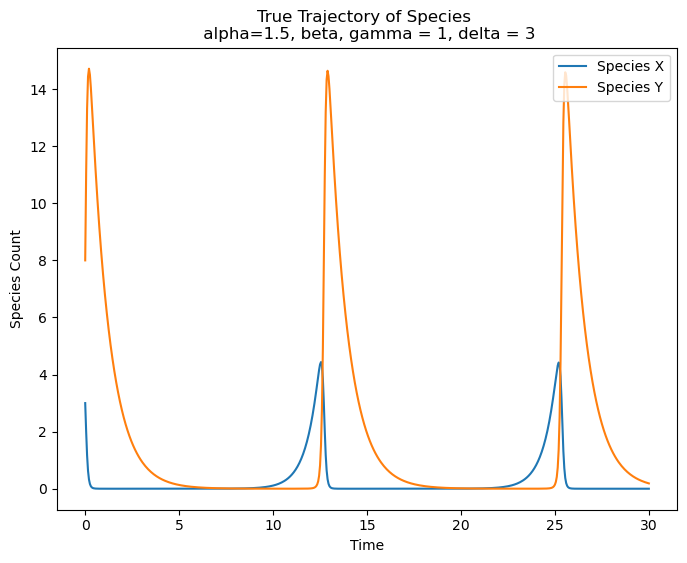

C:\Users\William\AppData\Local\Temp\ipykernel_51540\3060665997.py:22: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


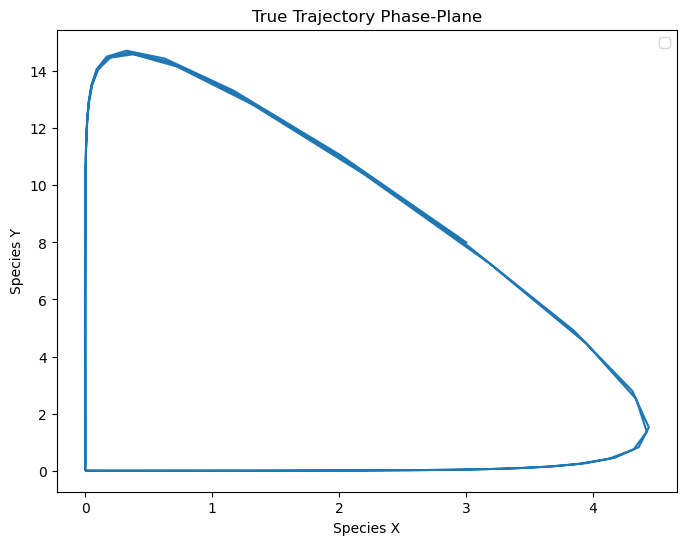

In [303]:
# check
# 0 collapses
lv_sol_x = lv_outputs[1][0]
lv_sol_y = lv_outputs[1][1]
lv_sol_t = lv_sol.t

plt.figure(figsize=(8, 6))
plt.plot(lv_sol_t, lv_sol_x, label="Species X")
plt.plot(lv_sol_t, lv_sol_y, label="Species Y")
plt.title(f"True Trajectory of Species \n alpha={lv_params['alpha']}, beta, gamma = {lv_params['beta']}, delta = {lv_params['delta']}")
plt.xlabel("Time")
plt.ylabel("Species Count")
plt.legend()
plt.show()

# plot phase-planes- pred
plt.figure(figsize=(8, 6))
plt.plot(lv_sol_x, lv_sol_y)
plt.xlabel("Species X")
plt.ylabel("Species Y")
plt.title("True Trajectory Phase-Plane")
plt.legend()
plt.show()

# Fit SINDy to the generated data

In [304]:
# first try individual sets of trajectories - a good one

X = lv_outputs[1].T
feat_names = list(lv_species_init.keys())
print(feat_names)

display(sindy_model.fit(X, t=timepts, feature_names=feat_names))
sindy_model.print()

['x', 'y']


,optimizer,STLSQ()
,feature_library,PolynomialLibrary(degree=3)
,differentiation_method,SmoothedFiniteDifference()
,degree,3
,include_interaction,True
,interaction_only,False
,include_bias,True
,order,'C'
,threshold,0.1
,alpha,0.05
,max_iter,20


(x)' =  0.700 x +  0.772 x^2 + -0.909 x y + -0.156 x^3
(y)' =  2.378 x + -0.917 y + -2.297 x^2 +  2.665 x y +  0.467 x^3


In [305]:
# def sindy_ode(t, y):

print(lv_outputs[1][:, 0])
print([X.T[:, 0]])

start_vals = X.T[:, 0].reshape(1, -1)

dX_dt = sindy_model.predict(X)
dx_dt_pred = dX_dt[:, 0] # first col
dy_dt_pred = dX_dt[:, 1] # second col
print(dX_dt)

[3. 8.]
[array([3., 8.])]
[[-1.69862648e+01  5.56747301e+01]
 [-1.69202632e+01  4.82820411e+01]
 [-1.25107618e+01  2.96145329e+01]
 ...
 [ 2.14274765e-05 -1.89063029e-01]
 [ 2.32744457e-05 -1.79825201e-01]
 [ 2.52623724e-05 -1.71041566e-01]]


[-1.69862648e+01 -1.69202632e+01 -1.25107618e+01 -7.51215319e+00
 -4.03949534e+00 -2.08218876e+00 -1.06721531e+00 -5.55012288e-01
 -2.95247164e-01 -1.61122202e-01 -9.03922211e-02 -5.21334332e-02
 -3.08792472e-02 -1.87701370e-02 -1.16955392e-02 -7.46023113e-03
 -4.86731817e-03 -3.24543411e-03 -2.20830005e-03 -1.53204654e-03
 -1.08186973e-03 -7.78092297e-04 -5.69147686e-04 -4.22801235e-04
 -3.18790133e-04 -2.43821384e-04 -1.89145735e-04 -1.48625906e-04
 -1.18317446e-04 -9.51139285e-05 -7.73169770e-05 -6.34584643e-05
 -5.26074802e-05 -4.38545107e-05 -3.67749643e-05 -3.11609509e-05
 -2.66631809e-05 -2.29319814e-05 -1.98736308e-05 -1.73562503e-05
 -1.52208647e-05 -1.34202135e-05 -1.19149424e-05 -1.06567449e-05
 -9.58536244e-06 -8.65050072e-06 -7.81148440e-06 -7.04368843e-06
 -6.36023738e-06 -5.75020949e-06 -5.20039335e-06 -4.69948117e-06
 -4.23836611e-06 -3.81304484e-06 -3.41780905e-06 -3.04690552e-06
 -2.69525995e-06 -2.35848743e-06 -2.03393772e-06 -1.71858487e-06
 -1.40925551e-06 -1.10300

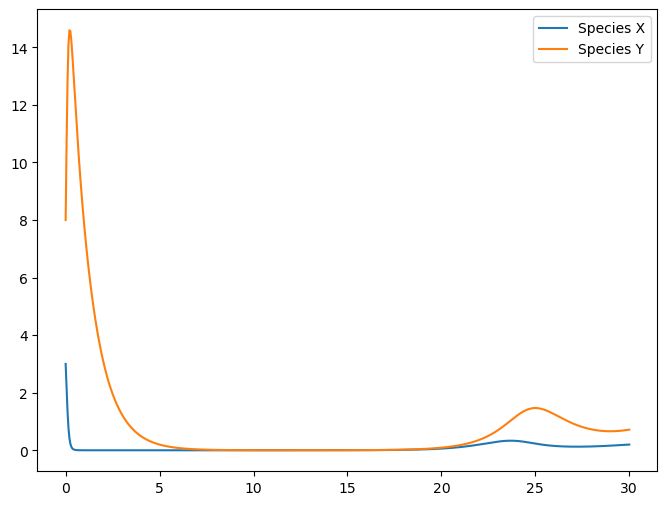

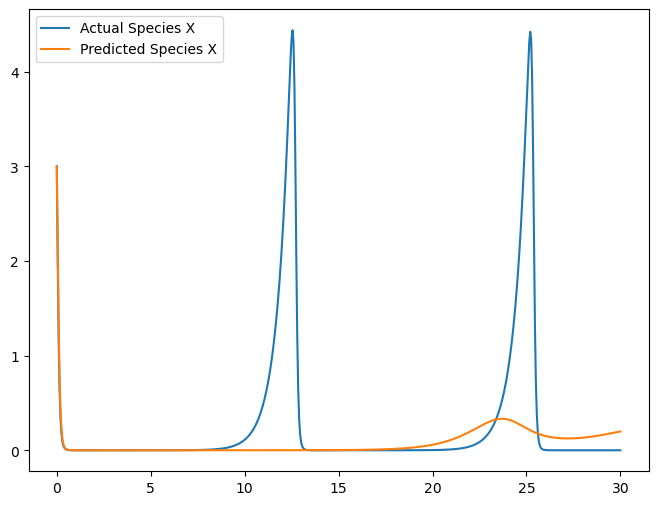

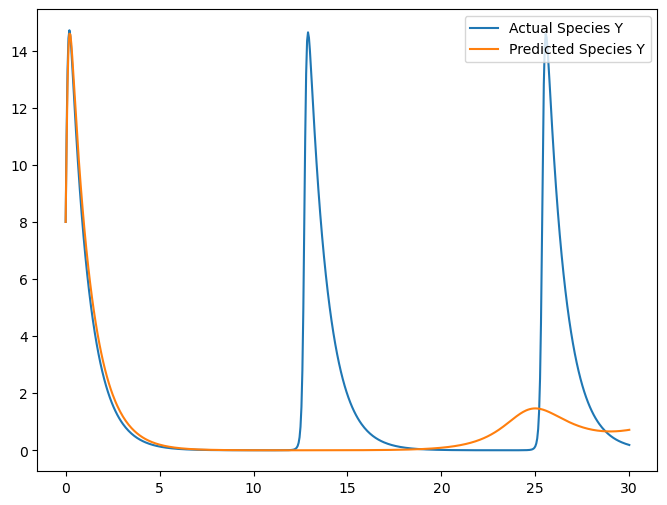

In [306]:
def make_sindy_ODEs(model):
    """
    makes an ODEFunc that I can give to solve_ivp
    t is the time defining length of sim- t_eval
    y is the 2D state vector defining state matrix
    """
    def sindy_pred_ODEs(t, y):
        # print(model.predict(y.reshape(1, -1)).flatten())
        return model.predict(y.reshape(1, -1)).flatten()
    return sindy_pred_ODEs

y0 = X[0, :]

sindy_pred_lv_ODEs = make_sindy_ODEs(sindy_model)
lv_pred_sol = sim_ODE_output(sindy_pred_lv_ODEs, y0, timepts)

print(dx_dt_pred)

# print(dy_dt)

lv_pred_x = lv_pred_sol.y[0]
lv_pred_y = lv_pred_sol.y[1]


# plot the predictions from the data together
plt.figure(figsize=(8, 6))
plt.plot(lv_sol_t, lv_pred_x, label="Species X")
plt.plot(lv_sol_t, lv_pred_y, label="Species Y")
plt.legend()
plt.show()

# plot each predicted trajectory vs. actual trajectory
plt.figure(figsize=(8, 6))
plt.plot(lv_sol_t, lv_sol_x, label="Actual Species X")
plt.plot(lv_sol_t, lv_pred_x, label="Predicted Species X")
plt.legend()
plt.show()

plt.figure(figsize=(8, 6))
plt.plot(lv_sol_t, lv_sol_y, label="Actual Species Y")
plt.plot(lv_sol_t, lv_pred_y, label="Predicted Species Y")
plt.legend()
plt.show()

# Convert model attributes into symbolic expressions

In [307]:
# sympy-ification code

# parse 
def parse_feature(name, sym_dict):
    """
    parses strings and matches them to symbolic representations
    name: an element of the function library, in string form
    sym_dict: dict of string names of vars to symbols
    will need further work if symbols become more complicated
    """
    # special case- constant
    if name == '1':
        return sp.Integer(1)
    expr = name
    # for k in sym_dict:
    #     # replace string/character k with the symbol in dict
    #     expr = expr.replace(k, f"sym_dict['{k}']")
    #     # exponents
    #     expr = expr.replace("^", "**")
    #     # multiplication
    #     expr = expr.replace(" ", "*")
    # # eval executes the constructed string as python code
    # return eval(expr)
    # alternate version
    # exponents
    expr = expr.replace("^", "**")
    # multiplication
    expr = expr.replace(" ", "*")
    # return using sympy's built-in parser
    return parse_expr(expr, local_dict=sym_dict, evaluate=True)

def sindy_to_sympy(model, var_names=None):
    """
    model: fitted sindy model, containing coefficients and feature names (library functions)
    var_names: list of strings, names of species in the ODE system- must explicitly provide if did not in sindy model.fit
    """
    var_names = var_names if var_names is not None else model.feature_names
    # symbols = sp.symbols(list(var_names))
    symbols = [sp.symbols(v) for v in var_names]
    # dict of species variable names (strings) to sympy symbols
    sym_dict = dict(zip(var_names, symbols))
    
    # get function library terms
    feature_names = model.get_feature_names()
    # get model coefficients
    Xi = model.coefficients().T

    # convert feature name strings into symbolic terms    
    features = [parse_feature(f, sym_dict) for f in feature_names]
    # print("len features", len(features))
    # print("shape Xi", Xi.shape)
    
    # build equations
    equations = []
    # for as many equations as implied by number of columns
    for j in range(Xi.shape[1]):
        eq = sum(Xi[i, j] * features[i] for i in range(len(features)))
        # eq = 0
        # for i in range(len(features)):
        #     eq += Xi[i, j] * features[i]
        equations.append(sp.simplify(eq))
    
    return symbols, equations

# lambdified function wrapper for solve_ivp
def wrap_lambdified_ode(lambdified_func):
    """
    lambdified func is a lambdified function
    """
    def sindy_learned_odes(t, y):
        """
        in format expected by solve_ivp
        y is the vector of states (species)
        """
        return lambdified_func(*y)
    return sindy_learned_odes

In [308]:
# get species names from the dict- repeated line for clarity/explicitness
feat_names = list(lv_species_init.keys())

# initial conditions- first row of state matrix
y0 = X[0, :]

# symbols, equations = sindy_to_sympy(sindy_model, feat_names)

symbols, equations = sindy_to_sympy(sindy_model, feat_names)

print(symbols)
print(equations)

rounded_equations = [eq.evalf(4) for eq in equations]  # ~3 decimal places
print(sp.latex(rounded_equations))

def round_expr(expr, n=3):
    return expr.xreplace({
        num: sp.Float(round(num, n))
        for num in expr.atoms(sp.Float)
    })

rounded_equations = [round_expr(eq, 3) for eq in equations]

print(sp.latex(rounded_equations))

# returns math as lambdified function
sindy_lv_odes_lambdified = sp.lambdify(symbols, equations, modules="numpy")

sindy_lv_odes = wrap_lambdified_ode(sindy_lv_odes_lambdified)
lv_sol_pred = sim_ODE_output(sindy_lv_odes, y0, timepts)



[x, y]
[x*(-0.156414533343514*x**2 + 0.771889973933509*x - 0.908709765671285*y + 0.699650745703093), 0.46662815792891*x**3 - 2.29726174765589*x**2 + 2.66468629315079*x*y + 2.37830221490111*x - 0.917031513152465*y]
\left[ x \left(- 0.1564 x^{2} + 0.7719 x - 0.9087 y + 0.6997\right), \  0.4666 x^{3} - 2.297 x^{2} + 2.665 x y + 2.378 x - 0.917 y\right]
\left[ x \left(- 0.156 x^{2} + 0.772 x - 0.909 y + 0.7\right), \  0.467 x^{3} - 2.297 x^{2} + 2.665 x y + 2.378 x - 0.917 y\right]


# Plotting and Evaluation Metrics

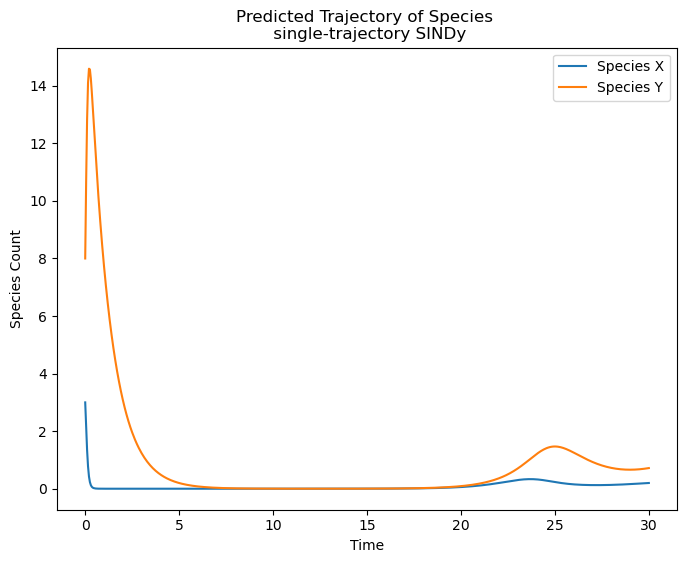

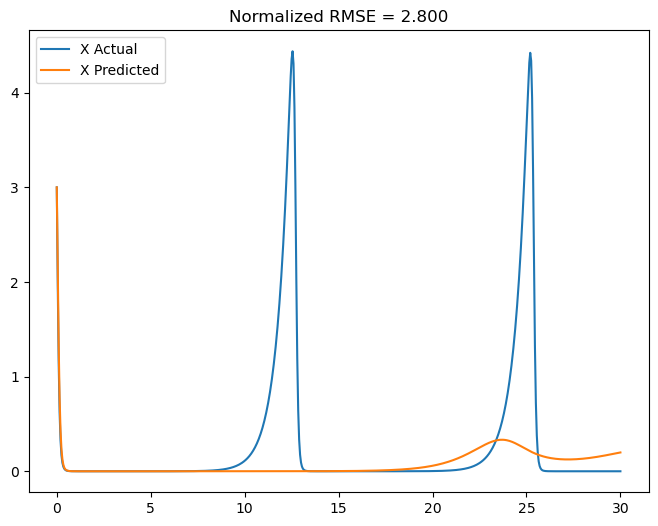

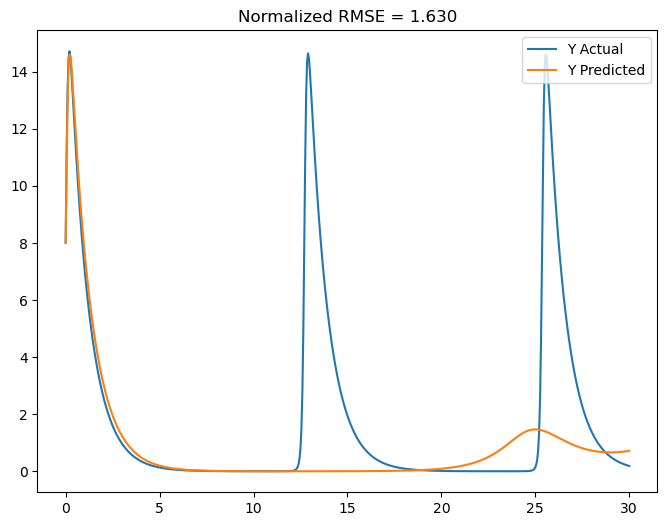

In [309]:
# plot
lv_pred_x = lv_sol_pred.y[0]
lv_pred_y = lv_sol_pred.y[1]


# plot the predictions from the data together
plt.figure(figsize=(8, 6))
plt.plot(lv_sol_t, lv_pred_x, label="Species X")
plt.plot(lv_sol_t, lv_pred_y, label="Species Y")
plt.title(f"Predicted Trajectory of Species \n single-trajectory SINDy")
plt.xlabel("Time")
plt.ylabel("Species Count")
plt.legend()
plt.show()

# calc rmse- naive because errors propagate and don't really reflect whether behavior follows, just pure error
rmse_x = root_mean_squared_error(lv_sol_x, lv_pred_x)/np.mean(lv_sol_x)

# plot each predicted trajectory vs. actual trajectory
plt.figure(figsize=(8, 6))
plt.plot(lv_sol_t, lv_sol_x, label="X Actual")
plt.plot(lv_sol_t, lv_pred_x, label="X Predicted")
plt.title(f"Normalized RMSE = {rmse_x:.3f}")
plt.legend()
plt.show()


rmse_y = root_mean_squared_error(lv_sol_y, lv_pred_y)/np.mean(lv_sol_y)

plt.figure(figsize=(8, 6))
plt.plot(lv_sol_t, lv_sol_y, label="Y Actual")
plt.plot(lv_sol_t, lv_pred_y, label="Y Predicted")
plt.title(f"Normalized RMSE = {rmse_y:.3f}")
plt.legend()
plt.show()

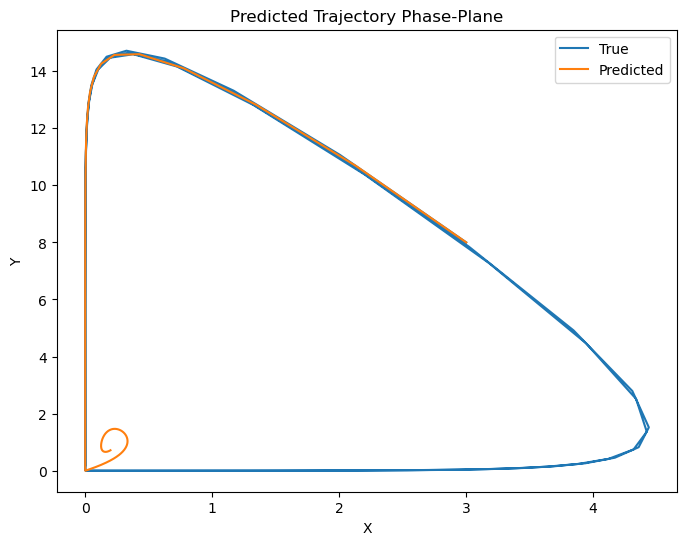

In [310]:
# plot phase-planes- pred
plt.figure(figsize=(8, 6))
plt.plot(lv_sol_x, lv_sol_y, label="True")
plt.plot(lv_pred_x, lv_pred_y, label="Predicted")
plt.xlabel("X")
plt.ylabel("Y")
plt.title("Predicted Trajectory Phase-Plane")
plt.legend()
plt.show()

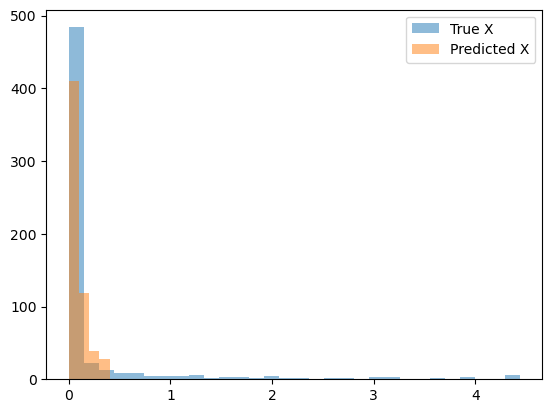

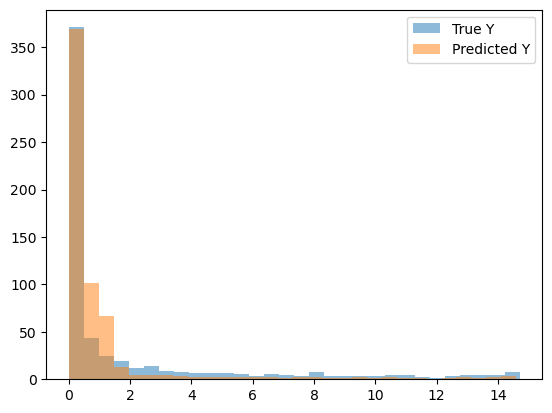

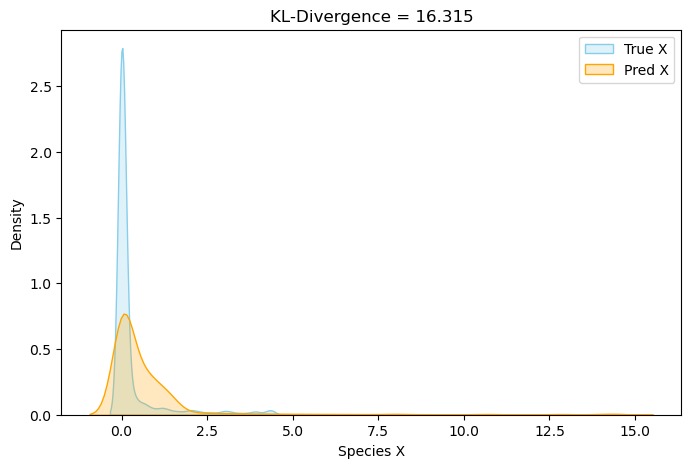

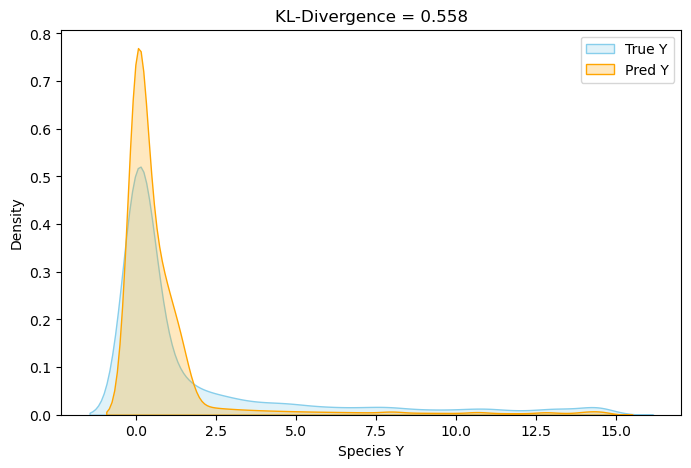

C:\Users\William\AppData\Local\Temp\ipykernel_51540\1768045.py:54: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


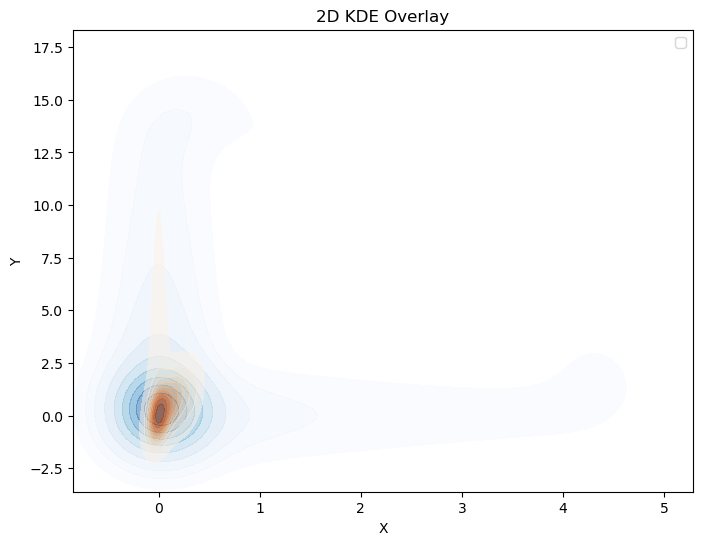

In [311]:
# plot histogram- distribution of points
# X
plt.hist(lv_sol_x, bins=30, alpha=0.5, label="True X")
plt.hist(lv_pred_x, bins=30, alpha=0.5, label="Predicted X")
plt.legend()
plt.show()

# Y
plt.hist(lv_sol_y, bins=30, alpha=0.5, label="True Y")
plt.hist(lv_pred_y, bins=30, alpha=0.5, label="Predicted Y")
plt.legend()
plt.show()

# kl diveergence of the distrib of x values
pad = 1e-12
hist_true_x, bins_true_x = np.histogram(lv_sol_x, bins=30, density=True)
hist_pred_x, bins_pred_x = np.histogram(lv_pred_x, bins=30, density=True)
hist_true_x_safe, hist_pred_x_safe = hist_true_x + pad, hist_pred_x + pad
kl_x = np.sum(hist_true_x_safe * np.log2(hist_true_x_safe/hist_pred_x_safe))
# print(kl_x)

# kde plot showing density
plt.figure(figsize=(8, 5))
sns.kdeplot(data=lv_sol_x, fill=True, color='skyblue', bw_adjust=0.5, label="True X")
sns.kdeplot(data=lv_pred_y, fill=True, color='orange', bw_adjust=0.5, label="Pred X")
plt.title(f"KL-Divergence = {kl_x:.3f}")
plt.xlabel("Species X")
plt.legend()
plt.show()

# kl diveergence of the distrib of y values
pad = 1e-12
hist_true_y, bins_true_y = np.histogram(lv_sol_y, bins=30, density=True)
hist_pred_y, bins_pred_y = np.histogram(lv_pred_y, bins=30, density=True)
hist_true_y_safe, hist_pred_y_safe = hist_true_y + pad, hist_pred_y + pad
kl_y = np.sum(hist_true_y_safe * np.log2(hist_true_y_safe/hist_pred_y_safe))
# print(kl_x)

plt.figure(figsize=(8, 5))
sns.kdeplot(data=lv_sol_y, fill=True, color='skyblue', bw_adjust=0.5, label="True Y")
sns.kdeplot(data=lv_pred_y, fill=True, color='orange', bw_adjust=0.5, label="Pred Y")
plt.title(f"KL-Divergence = {kl_y:.3f}")
plt.xlabel("Species Y")
plt.legend()
plt.show()

# try both species together?
plt.figure(figsize=(8,6))
sns.kdeplot(x=lv_sol_x, y=lv_sol_y, fill=True, cmap='Blues', alpha=0.5, label='True')
sns.kdeplot(x=lv_pred_x, y=lv_pred_y, fill=True, cmap='Oranges', alpha=0.5, label='Pred')
plt.xlabel("X")
plt.ylabel("Y")
plt.title("2D KDE Overlay")
plt.legend()
plt.show()

# try the thing at the bottom of the evaluation page of their documentation?


# Fit SINDy to all of the generated data

In [312]:
# now try training on multiple trajectories

# give it a list of each trajectory, time by num_species
X_all = [traj.T for traj in lv_outputs if traj is not None]

t_all = [timepts for _ in X_all]
print(len(t_all))

feat_names = list(lv_species_init.keys())
print(feat_names)

display(sindy_model.fit(X_all, t=t_all, feature_names=feat_names))
sindy_model.print()

10
['x', 'y']


,optimizer,STLSQ()
,feature_library,PolynomialLibrary(degree=3)
,differentiation_method,SmoothedFiniteDifference()
,degree,3
,include_interaction,True
,interaction_only,False
,include_bias,True
,order,'C'
,threshold,0.1
,alpha,0.05
,max_iter,20


(x)' = -7378.483 1 +  1.503 x +  6629.625 y + -6084.738 x y + -283.944 y^2 +  110.039 x y^2 +  3.020 y^3
(y)' =  1.049 x y


# Sympy to extract equations and plot

In [313]:
# get species names from the dict- repeated line for clarity/explicitness
feat_names = list(lv_species_init.keys())

# initial conditions- first row of state matrix
y0 = X_all[1][0, :]

# symbols, equations = sindy_to_sympy(sindy_model, feat_names)

symbols, equations = sindy_to_sympy(sindy_model, feat_names)

print(symbols)
print(equations)

# print latex
rounded_equations = [eq.evalf(4) for eq in equations]  # ~3 decimal places
print(sp.latex(rounded_equations))

def round_expr(expr, n=3):
    return expr.xreplace({
        num: sp.Float(round(num, n))
        for num in expr.atoms(sp.Float)
    })

rounded_equations = [round_expr(eq, 3) for eq in equations]

print(sp.latex(rounded_equations))

# returns math as lambdified function
sindy_lv_odes_lambdified = sp.lambdify(symbols, equations, modules="numpy")

sindy_lv_odes = wrap_lambdified_ode(sindy_lv_odes_lambdified)
lv_sol_pred = sim_ODE_output(sindy_lv_odes, y0, timepts)

[x, y]
[110.038547263939*x*y**2 - 6084.73773272013*x*y + 1.50291808439354*x + 3.01976876350339*y**3 - 283.944410994696*y**2 + 6629.62500179647*y - 7378.48338295593, 1.04881202920613*x*y]
\left[ 110.0 x y^{2} - 6085.0 x y + 1.503 x + 3.02 y^{3} - 283.9 y^{2} + 6630.0 y - 7378.0, \  1.049 x y\right]
\left[ 110.039 x y^{2} - 6084.738 x y + 1.503 x + 3.02 y^{3} - 283.944 y^{2} + 6629.625 y - 7378.483, \  1.049 x y\right]


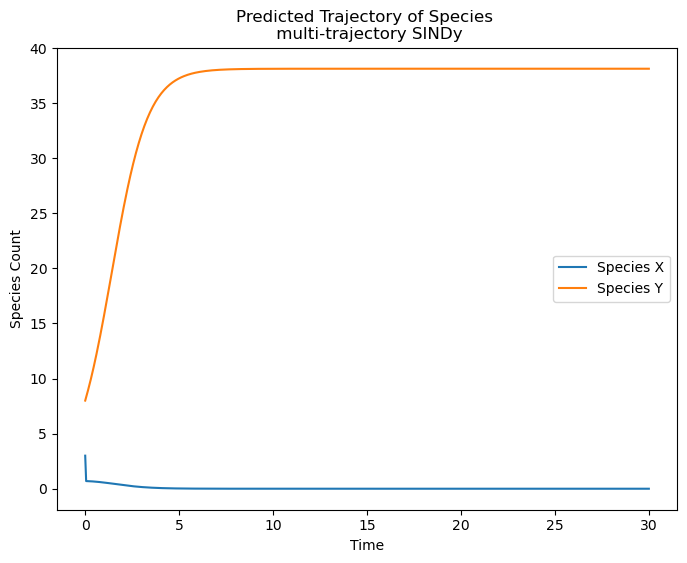

In [314]:
# plot
lv_pred_x = lv_sol_pred.y[0]
lv_pred_y = lv_sol_pred.y[1]


# plot the predictions from the data together
plt.figure(figsize=(8, 6))
plt.plot(lv_sol_t, lv_pred_x, label="Species X")
plt.plot(lv_sol_t, lv_pred_y, label="Species Y")
plt.title(f"Predicted Trajectory of Species \n multi-trajectory SINDy")
plt.xlabel("Time")
plt.ylabel("Species Count")
plt.legend()
plt.show()

In [315]:
# # first try individual sets of trajectories - the messed-up collapse case

# X = lv_outputs[0].T
# feat_names = list(lv_species_init.keys())
# print(feat_names)

# display(sindy_model.fit(X, t=timepts, feature_names=feat_names))
# sindy_model.print()